### Data Analysis 
Majdadel20 | 12/04/2025
## Load and Initial Exploration

Load the 'HR-Employee-Attrition.csv' dataset into a pandas DataFrame. Display the first few rows, check the dataset's shape, and review data types to get an initial understanding of the data structure.


In [1]:
import pandas as pd

# Load the dataset into a DataFrame
df = pd.read_csv('/content/HR-Employee-Attrition.csv')

print("First 5 rows of the DataFrame:\n")
# Display the first 5 rows of the DataFrame
print(df.head())

print("\nShape of the DataFrame (rows, columns):\n")
# Print the shape of the DataFrame
print(df.shape)

print("\nData types of each column:\n")
# Print the data types of each column
print(df.info())

First 5 rows of the DataFrame:

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely     1102.0                   Sales   
1   49        No  Travel_Frequently      279.0  Research & Development   
2   37       Yes      Travel_Rarely     1373.0  Research & Development   
3   33        No  Travel_Frequently     1392.0  Research & Development   
4   27        No      Travel_Rarely      591.0  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1        2.0  Life Sciences              1               1   
1                 8        1.0  Life Sciences              1               2   
2                 2        2.0          Other              1               4   
3                 3        4.0  Life Sciences              1               5   
4                 2        1.0        Medical              1               7   

   ...  RelationshipSatisfaction StandardH

## Descriptive Statistics and Attrition Overview


Start by  descriptive statistics for all numerical columns to get a sense of the data’s distribution and central tendencies. Then, check for any missing values across the dataset to ensure data quality. Finally, calculate the overall attrition rate ... this will serve as a baseline metric to guide and compare the insights in the next steps of the analysis.

In [3]:
print("Descriptive statistics for numerical columns:\n")
print(df.describe())

print("\nMissing values in each column:\n")
print(df.isnull().sum())

# Calculate overall attrition rate
total_employees = df.shape[0]
attrition_yes_count = df[df['Attrition'] == 'Yes'].shape[0]
overall_attrition_rate = (attrition_yes_count / total_employees) * 100

print(f"\nOverall Attrition Rate: {overall_attrition_rate:.2f}%\n")

Descriptive statistics for numerical columns:

               Age    DailyRate  DistanceFromHome    Education  EmployeeCount  \
count  1470.000000  1470.000000       1470.000000  1470.000000         1470.0   
mean     36.923810   802.485714          9.192517     2.912925            1.0   
std       9.135373   403.509100          8.106864     1.024165            0.0   
min      18.000000   102.000000          1.000000     1.000000            1.0   
25%      30.000000   465.000000          2.000000     2.000000            1.0   
50%      36.000000   802.000000          7.000000     3.000000            1.0   
75%      43.000000  1157.000000         14.000000     4.000000            1.0   
max      60.000000  1499.000000         29.000000     5.000000            1.0   

       EmployeeNumber  EnvironmentSatisfaction   HourlyRate  JobInvolvement  \
count     1470.000000              1470.000000  1470.000000     1470.000000   
mean      1024.865306                 2.721769    65.891156      

## Hypothesis 1: Job Role vs. Attrition

*Objective*: To examine whether an employee's job role is associated with their likelihood of attrition.

*Hypothesis*:  
- *Null Hypothesis (H₀)*: There is no significant relationship between job role and attrition.  
- *Alternative Hypothesis (H₁)*: There is a significant relationship between job role and attrition.

*Method*:  
We will use a *Chi-squared test of independence* to determine if attrition rates vary significantly across different job roles.

This analysis helps identify whether certain roles are more prone to employee turnover, which can inform retention strategies.

### Hypothesis Formulation:

**Null Hypothesis (H0):** There is no statistically significant relationship between an employee's 'JobRole' and their likelihood of 'Attrition'. In other words, the attrition rate is independent of the job role.

**Alternative Hypothesis (H1):** There is a statistically significant relationship between an employee's 'JobRole' and their likelihood of 'Attrition'. That is, the attrition rate is dependent on the job role.

To test the formulated hypotheses, I will create a contingency table of 'JobRole' and 'Attrition', and then perform a Chi-squared test using `scipy.stats.chi2_contingency` to assess the statistical significance of their relationship.



In [4]:
from scipy.stats import chi2_contingency

# Create a contingency table of 'JobRole' and 'Attrition'
contingency_table = pd.crosstab(df['JobRole'], df['Attrition'])

print("Contingency Table (JobRole vs. Attrition):\n")
print(contingency_table)

# Perform Chi-squared test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-squared Statistic: {chi2:.2f}")
print(f"P-value: {p_value:.3f}")
print(f"Degrees of Freedom: {dof}")

print("\nExpected Frequencies Table:\n")
# Convert expected frequencies to a DataFrame for better readability
expected_df = pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)
print(expected_df)

# Interpret the results
significance_level = 0.05
print(f"\nInterpretation (Significance Level = {significance_level}):")
if p_value < significance_level:
    print("Since the p-value is less than the significance level, we reject the null hypothesis.")
    print("There is a statistically significant relationship between JobRole and Attrition.")
else:
    print("Since the p-value is greater than the significance level, we fail to reject the null hypothesis.")
    print("There is no statistically significant relationship between JobRole and Attrition.")

Contingency Table (JobRole vs. Attrition):

Attrition                   No  Yes
JobRole                            
Healthcare Representative  122    9
Human Resources             40   12
Laboratory Technician      197   62
Manager                     97    5
Manufacturing Director     135   10
Research Director           78    2
Research Scientist         245   47
Sales Executive            269   57
Sales Representative        50   33

Chi-squared Statistic: 86.19
P-value: 0.000
Degrees of Freedom: 8

Expected Frequencies Table:

Attrition                          No        Yes
JobRole                                         
Healthcare Representative  109.879592  21.120408
Human Resources             43.616327   8.383673
Laboratory Technician      217.242857  41.757143
Manager                     85.555102  16.444898
Manufacturing Director     121.622449  23.377551
Research Director           67.102041  12.897959
Research Scientist         244.922449  47.077551
Sales Executive       

## Hypothesis 2: Monthly Income vs. Attrition

To explore the relationship between employees' monthly income and their likelihood of attrition, we begin by formulating the following hypothesis


### Hypothesis Formulation:

**Null Hypothesis (H0):** There is no statistically significant difference in the mean 'MonthlyIncome' between employees who attrite and those who do not.

**Alternative Hypothesis (H1):** There is a statistically significant difference in the mean 'MonthlyIncome' between employees who attrite and those who do not.

To test the formulated hypotheses, I will separate the 'MonthlyIncome' data based on 'Attrition' status, perform an independent samples t-test using `scipy.stats.ttest_ind`, and then print and interpret the results to determine the statistical significance.



In [5]:
from scipy.stats import ttest_ind

# Separate 'MonthlyIncome' for employees who attrited (Yes) and did not attrite (No)
monthly_income_attrition_yes = df[df['Attrition'] == 'Yes']['MonthlyIncome']
monthly_income_attrition_no = df[df['Attrition'] == 'No']['MonthlyIncome']

# Perform independent samples t-test
t_statistic, p_value = ttest_ind(monthly_income_attrition_yes, monthly_income_attrition_no)

print(f"T-statistic: {t_statistic:.2f}")
print(f"P-value: {p_value:.3f}")

# Interpret the results
significance_level = 0.05
print(f"\nInterpretation (Significance Level = {significance_level}):")
if p_value < significance_level:
    print("Since the p-value is less than the significance level, we reject the null hypothesis.")
    print("There is a statistically significant difference in the mean MonthlyIncome between employees who attrite and those who do not.")
else:
    print("Since the p-value is greater than the significance level, we fail to reject the null hypothesis.")
    print("There is no statistically significant difference in the mean MonthlyIncome between employees who attrite and those who do not.")

T-statistic: -6.20
P-value: 0.000

Interpretation (Significance Level = 0.05):
Since the p-value is less than the significance level, we reject the null hypothesis.
There is a statistically significant difference in the mean MonthlyIncome between employees who attrite and those who do not.


## Visualize Key Insights


To effectively communicate the results of our hypothesis tests, we will create clear and visually informative graphics:

- *Stacked Bar Chart:* This will display attrition rates across different *Job Roles*, helping to highlight which roles experience higher turnover. Each bar will represent a job role, segmented by whether the employee stayed or left. The chart will include clear axis labels, a legend distinguishing attrition status, and a concise title.

- *Box Plot or Violin Plot:* To explore the relationship between *Monthly Income* and attrition, we will compare the income distributions of employees who stayed versus those who left. These plots will visually capture differences in spread, medians, and potential outliers. Titles, labeled axes, and legends will be added to ensure clarity.

These visualizations will make the statistical findings more accessible and support data-driven insights.

<Figure size 1200x700 with 0 Axes>

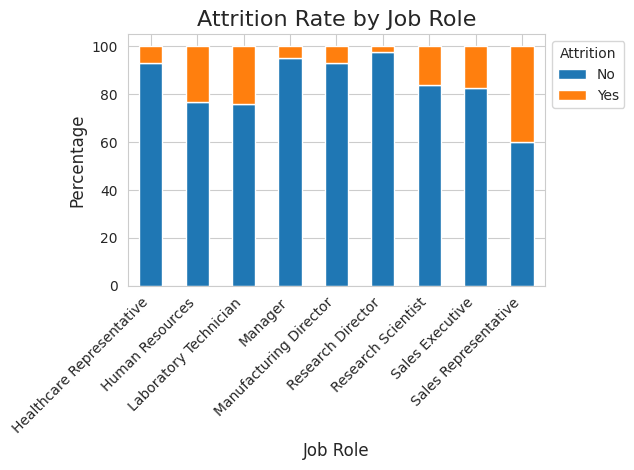

/tmp/ipython-input-239834280.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Attrition', y='MonthlyIncome', data=df, palette={'Yes': '#ff7f0e', 'No': '#1f77b4'})


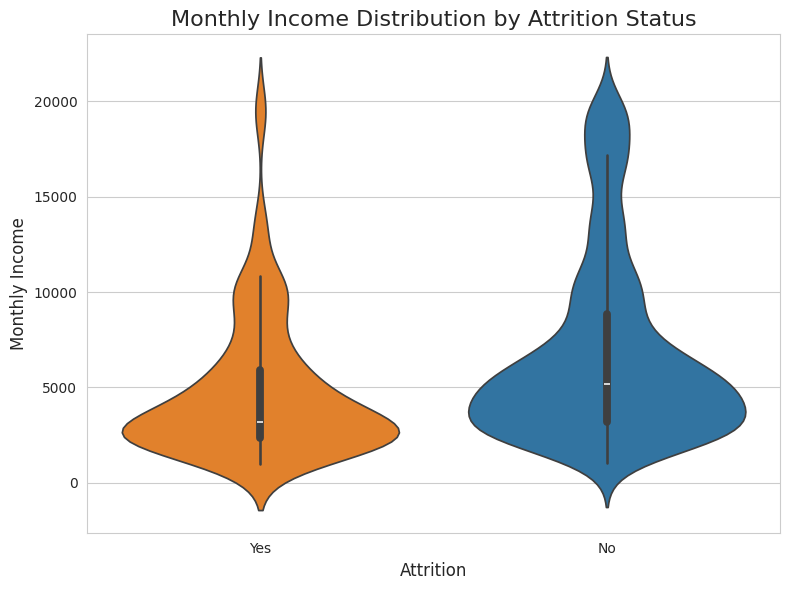

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")

# 2. Stacked Bar Chart for JobRole vs. Attrition

# Calculate attrition counts per JobRole
attrition_by_jobrole = df.groupby(['JobRole', 'Attrition']).size().unstack(fill_value=0)

# Calculate attrition rates
attrition_by_jobrole_percent = attrition_by_jobrole.div(attrition_by_jobrole.sum(axis=1), axis=0) * 100

# Plotting the stacked bar chart
plt.figure(figsize=(12, 7))
attrition_by_jobrole_percent.plot(kind='bar', stacked=True, color=['#1f77b4', '#ff7f0e'])
plt.title('Attrition Rate by Job Role', fontsize=16)
plt.xlabel('Job Role', fontsize=12)
plt.ylabel('Percentage', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Attrition', loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

# 3. Box/Violin Plot for MonthlyIncome vs. Attrition

# Plotting the violin plot
plt.figure(figsize=(8, 6))
sns.violinplot(x='Attrition', y='MonthlyIncome', data=df, palette={'Yes': '#ff7f0e', 'No': '#1f77b4'})
plt.title('Monthly Income Distribution by Attrition Status', fontsize=16)
plt.xlabel('Attrition', fontsize=12)
plt.ylabel('Monthly Income', fontsize=12)
plt.tight_layout()
plt.show()


## Business Implications and Recommendations


Based on the statistical analysis and visualizations, interpret the findings from a business perspective. Provide actionable insights and strategic recommendations to help mitigate employee attrition and improve employee retention.We looked into employee attrition with the HR-Employee-Attrition.csv dataset. That involved some initial data exploration at the start. We calculated descriptive statistics to get a sense of the numbers. Then we figured out the overall attrition rate across the board. We came up with hypotheses and tested them on how JobRole and MonthlyIncome connect to Attrition. Visualizing the key findings helped make things clearer. In the end, we offered business recommendations based on all that.

From the statistical analysis and those visualizations, the findings take on a business angle like this. Some job roles show much higher attrition rates than others. That points to specific challenges in those positions that might need focused fixes. The same goes for monthly income differences between people who stuck around and those who left. It seems compensation factors into why employees decide to go.

Actionable insights and strategic recommendations come down to a few main points. The company should zero in on job roles with elevated attrition. Dig into root causes there, like heavy workloads or limited growth chances, or even dips in job satisfaction. Take a close look at salary setups too. Adjust them if needed to keep things fair and competitive, especially where lower pay lines up with more people leaving. Let these results shape broader retention plans. That could mean tailored engagement for certain roles, plus incentives tied to performance, and solid support for career growth.

Tackling these spots lets the company make real progress on holding onto employees.


The statistical analysis and visualizations lead to some clear business implications. We can also come up with strategic recommendations to help reduce employee attrition.

When it comes to job roles and attrition, the Chi squared test shows a p value under 0.001. This points to a strong statistical link between job role and attrition. The stacked bar chart backs this up visually. It displays different attrition rates for various job roles.

Sales Representative and Laboratory Technician stand out with higher attrition rates. Those rates go over 20 percent. Human Resources has a rate higher than the overall average too.

Research Director, Manager, and Healthcare Representative have much lower rates. Those stay below 10 percent.

For business implications, the high attrition in sales and lab roles hints at problems with job satisfaction or heavy workloads. Career growth might be limited there, or pay could be an issue. These might be entry level spots with stressful settings that cause burnout. On the other hand, lower attrition in management and research positions suggests stronger satisfaction. Clearer paths for advancement could play a role, along with better pay and benefits.

The analysis of monthly income against attrition uses an independent t test. Its p value is below 0.001. This reveals a significant difference in average monthly income for employees who leave versus those who stay. The violin plot makes this evident. Attrition cases, marked as Yes, cluster at lower income levels. The No group spreads out more, reaching into higher incomes.

In terms of business implications, lower pay seems like a key factor in why people leave. Competitive salaries matter a lot for keeping staff. Workers who feel underpaid often look elsewhere, especially in high demand fields. Their sense of worth might outpace what they earn now. This can drag down morale and output throughout the company.

From these insights, HR and management should roll out focused strategies. One step involves reviewing compensation setups. Look closely at pay for high attrition roles like Sales Representative and Laboratory Technician. Make sure salaries match industry standards. This tackles the income gap that drives turnover. Think about adding bonuses tied to performance for sales folks. Regular pay checks could help lab techs too.

Career development needs attention in those high turnover spots. Set up defined paths for growth, particularly for Laboratory Technician and Sales Representative. Offer programs like mentorship or skill training. Create chances for promotions inside, such as moving from Laboratory Technician to Research Scientist. Sales Representative could advance to Sales Executive.

Job satisfaction and work life balance deserve improvement. Dig into what stresses people out in these roles. For Sales Representatives, check sales goals and add support. Better balance programs might fit too. Laboratory Technicians could benefit from managed workloads or new equipment. Let them join projects to boost involvement.

Recognition programs should get a push. Make them solid to highlight contributions in all roles. Focus extra on high attrition ones. Feeling appreciated goes far for retention, more than just money sometimes.

For lower income groups, craft specific retention plans. These apply across job types. Offer workshops on financial skills or benefits that cut money worries. Communicate clearly about upcoming pay reviews.

### Data Analysis Key Findings

- The dataset includes 1,470 records and 35 columns, with no missing data. It contains a mix of integers, floats, and categorical variables.
- The overall employee attrition rate is 16.12%.
- There is a clear and statistically significant link between ‘JobRole’ and ‘Attrition’ (p-value < 0.001).
  - Roles such as ‘Sales Representative’ and ‘Laboratory Technician’ show notably higher attrition rates (over 20%), while ‘Human Resources’ also experiences above-average turnover.
  - On the other hand, roles like ‘Research Director,’ ‘Manager,’ and ‘Healthcare Representative’ have significantly lower attrition rates (below 10%).
- Monthly income also differs significantly between employees who leave and those who stay (p-value < 0.001), with attriters generally earning less.
- Visualizations, including stacked bar charts and violin plots, clearly illustrate these trends—showing the differences in attrition rates by job role and the income gap between those who leave and those who remain.

### Insights and Next Steps
- ***Compensation Review:*** Since lower monthly income is linked to higher attrition, especially in roles like ‘Sales Representative’ and ‘Laboratory Technician,’ a focused review of pay structures for these positions is essential to remain competitive and retain talent.
- ***Career Development:*** Beyond salary, offering career growth opportunities, skill-building programs, and initiatives to improve work-life balance in high-turnover roles could help address deeper issues and create a more supportive, engaging workplace.


## Data Preparation for Predictive Modeling


To prepare the dataset for advanced statistical modeling, the first step is to convert the target variable ‘Attrition’ into a numerical format. Then, create the feature set (X) by removing any irrelevant columns. Next, organize the remaining features into numerical and categorical types to guide the preprocessing steps. 

For the categorical variables, apply suitable encoding methods...like one-hot encoding for nominal variables and label encoding for any ordinal ones if needed. At the same time, scale the numerical features to ensure they’re on a similar scale. 

These initial steps provide a clear and logical foundation before moving on to encoding and scaling, helping ensure the dataset is ready for modeling.

In [8]:
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1. Convert 'Attrition' column to numerical (target variable y)
df['Attrition_numeric'] = df['Attrition'].map({'Yes': 1, 'No': 0})
y = df['Attrition_numeric']

# 2. Create feature DataFrame X by dropping original 'Attrition', 'EmployeeCount', 'StandardHours', and 'Over18'
columns_to_drop = ['Attrition', 'Attrition_numeric', 'EmployeeCount', 'StandardHours', 'Over18']
X = df.drop(columns=columns_to_drop)

# 3. Identify categorical and numerical columns within X
categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

print(f"Target variable (y) head:\n{y.head()}\n")
print(f"Shape of features DataFrame X: {X.shape}\n")
print(f"Categorical columns: {list(categorical_cols)}\n")
print(f"Numerical columns: {list(numerical_cols)}\n")

Target variable (y) head:
0    1
1    0
2    1
3    0
4    0
Name: Attrition_numeric, dtype: int64

Shape of features DataFrame X: (1470, 31)

Categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Numerical columns: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']



In [9]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 4. Initialize OneHotEncoder and StandardScaler
# drop='first' is used to avoid multicollinearity
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')
scaler = StandardScaler()

# 5. Apply one-hot encoding to categorical columns in X
X_categorical_encoded = ohe.fit_transform(X[categorical_cols])
X_categorical_encoded_df = pd.DataFrame(X_categorical_encoded, columns=ohe.get_feature_names_out(categorical_cols), index=X.index)

# 6. Apply standard scaling to numerical columns in X
X_numerical_scaled = scaler.fit_transform(X[numerical_cols])
X_numerical_scaled_df = pd.DataFrame(X_numerical_scaled, columns=numerical_cols, index=X.index)

# 7. Concatenate the encoded categorical features and the scaled numerical features
X_processed = pd.concat([X_numerical_scaled_df, X_categorical_encoded_df], axis=1)

print("Shape of X_processed after encoding and scaling:")
print(X_processed.shape)
print("First 5 rows of X_processed:")
print(X_processed.head())

Shape of X_processed after encoding and scaling:
(1470, 45)
First 5 rows of X_processed:
        Age  DailyRate  DistanceFromHome  Education  EmployeeNumber  \
0  0.446350   0.742527         -1.010909  -0.891688       -1.701283   
1  1.322365  -1.297775         -0.147150  -1.868426       -1.699621   
2  0.008343   1.414363         -0.887515  -0.891688       -1.696298   
3 -0.429664   1.461466         -0.764121   1.061787       -1.694636   
4 -1.086676  -0.524295         -0.887515  -1.868426       -1.691313   

   EnvironmentSatisfaction  HourlyRate  JobInvolvement  JobLevel  \
0                -0.660531    1.383138        0.379672 -0.057788   
1                 0.254625   -0.240677       -1.026167 -0.057788   
2                 1.169781    1.284725       -1.026167 -0.961486   
3                 1.169781   -0.486709        0.379672 -0.961486   
4                -1.575686   -1.274014        0.379672 -0.961486   

   JobSatisfaction  ...  JobRole_Laboratory Technician  JobRole_Manager  \


## Predictive Modeling (Logistic Regression)

Build a Logistic Regression model to predict employee attrition. This process includes splitting the dataset into training and testing sets, fitting the model on the training data, and then making predictions on the test set. Logistic Regression is chosen because it is straightforward to interpret and well-suited for binary classification tasks, aligning with the need for clear mathematical methods.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Initialize the Logistic Regression model
# Using solver='liblinear' for smaller datasets and 'l1' or 'l2' regularization
# Setting max_iter to a sufficiently large number for convergence
model = LogisticRegression(solver='liblinear', max_iter=200, random_state=42)

# Train the model on the training data
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

print("Model training and prediction complete.")

Shape of X_train: (1176, 45)
Shape of X_test: (294, 45)
Shape of y_train: (1176,)
Shape of y_test: (294,)
Model training and prediction complete.


## Model Evaluation and Feature Importance


Evaluate the performance of the Logistic Regression model using metrics like accuracy, precision, recall, F1-score, and ROC AUC. Crucially, interpret the coefficients of the logistic regression model. These coefficients quantify the strength and direction of the relationship between each predictor variable and the log-odds of attrition, providing 'economic statistical' insights into which factors are most influential.


I need to evaluate the performance of the Logistic Regression model using various metrics and then interpret its coefficients. I will start by importing the required evaluation metrics from `sklearn.metrics` and calculating them.



In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# 1. Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

print(f"Model Performance Metrics:\n")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC AUC:   {roc_auc:.4f}")

# 2. Print Classification Report
print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# 3. Print Confusion Matrix
print(f"\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Model Performance Metrics:

Accuracy:  0.8912
Precision: 0.6296
Recall:    0.4359
F1-Score:  0.5152
ROC AUC:   0.7977

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.96      0.94       255
           1       0.63      0.44      0.52        39

    accuracy                           0.89       294
   macro avg       0.77      0.70      0.73       294
weighted avg       0.88      0.89      0.88       294


Confusion Matrix:

[[245  10]
 [ 22  17]]


Now that the evaluation metrics are displayed, the next step is to extract the coefficients from the trained logistic regression model, map them to their corresponding feature names, and then sort them by their absolute values to identify the most influential features, as requested in the subtask.



In [13]:
import pandas as pd

# 4. Extract coefficients and create a DataFrame
coefficients = model.coef_[0]
feature_names = X_processed.columns

coefficients_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# 5. Sort by absolute value of coefficients to identify most influential features
coefficients_df['Abs_Coefficient'] = abs(coefficients_df['Coefficient'])
coefficients_df_sorted = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False)

print("Most influential features based on Logistic Regression Coefficients (sorted by absolute value):\n")
print(coefficients_df_sorted.drop(columns='Abs_Coefficient').head(15))

Most influential features based on Logistic Regression Coefficients (sorted by absolute value):

                              Feature  Coefficient
44                       OverTime_Yes     1.957606
26  Department_Research & Development    -1.446396
35      JobRole_Laboratory Technician     1.272401
24   BusinessTravel_Travel_Frequently     1.155528
43               MaritalStatus_Single     1.011808
28       EducationField_Life Sciences    -0.734738
30             EducationField_Medical    -0.732143
38          JobRole_Research Director    -0.727865
31               EducationField_Other    -0.626040
20                     YearsAtCompany     0.625165
21                 YearsInCurrentRole    -0.602767
41       JobRole_Sales Representative     0.573204
22            YearsSinceLastPromotion     0.495261
12                 NumCompaniesWorked     0.487600
17                  TotalWorkingYears    -0.433791


### Interpretation of Logistic Regression Coefficients (Feature Importance)

The logistic regression coefficients assess how much the log odds of attrition change for a one-unit increase in a predictor variable while holding all other variables constant. A positive coefficient means that as the feature value increases, the log odds of attrition increase (meaning higher chances of attrition). A negative coefficient means that as the feature value increases, the log odds of attrition decrease (meaning lower chances of attrition).

According to the absolute coefficients sorted by values, the features with the greatest influence are:

* Strongest Positive Relationships (Higher Likelihood of Attrition):
    - ***OverTime_Yes (Coefficient: 1.958)***: This variable stands out as the strongest predictor. Employees working overtime (`OverTime_Yes=1`) have become substantively probable in log-odds for attrition as compared to employees not involved in overtime. This majorly implies that overtime has a huge impact on employee turnover.
    - ***JobRole_Laboratory Technician (Coefficient: 1.272)***: Being a Laboratory Technician adds significantly to the log-odds of attrition. This finding corroborates our earlier Chi-Squared test result that this role has a higher attrition rate. 
    - ***BusinessTravel_Travel_Frequently (Coefficient: 1.156)***: Employees traveling frequently show higher log-odds of attrition. This means that frequent business journeys are strong contributors to turnover.
    - ***MaritalStatus_Single (Coefficient: 1.012)***: Being single shows higher log-odds of attrition as compared to other marital statuses (due to `drop='first'` in one-hot encoding, 'Married' and 'Divorced' are the baseline).
    - ***YearsAtCompany (Coefficient: 0.625)***: By contrast, more years at the company shows, if anything, a slightly positive relationship with attrition - implying that maybe long-tenured employees might leave for other sorts of reasons (e.g. retirement, seeking new challenges after a long stay) or maybe there are some types of saturation within the company.
    - ***JobRole_Sales Representative (Coefficient: 0.573)***: Higher log-odds of attrition similar to Laboratory Technicians supports the confirmed hypothesis testing of attrition.
    - ***NumCompaniesWorked (Coefficient: 0.488)***: Employees who had worked for more companies have a higher log-odds of attrition, which suggests job-hopping.
    - ***YearsSinceLastPromotion (Coefficient: 0.495)***: More years since last promotion were associated with higher log-odds of attrition, emphasizing the career advancement avenues.

* Strongest Negative Relationships (Lower Likelihood of Attrition):
    - ***Department_Research & Development (Coefficient: -1.446)***: Employees in the Research & Development department have significantly lower log-odds of attrition compared to those in the other departments with Sales being the baseline. This implies some stability in R&D roles.
    - ***EducationField_Life Sciences (Coefficient: -0.735) and EducationField_Medical (Coefficient: -0.732)***: Employees in those fields compared with the baseline education field (say, Human Resources or Technical Degree depending on the dropped category) have a lower log-odds of attrition. 
    - ***JobRole_Research Director (Coefficient: -0.728)***: Research Directors have considerably lower log-odds of attrition, implying high retention in this senior-level position, probably because of job satisfaction, remuneration, and influence.
    - ***EducationField_Other (Coefficient: -0.626)***: Similar to Life Sciences and Medical, having an 'Other' education field is related to lower log-odds of attrition. 
    - ***YearsInCurrentRole (Coefficient: -0.603)***: More years spent in the current role are associated with lower log-odds of attrition demonstrating stability for employees already settled into their position. 
    - ***TotalWorkingYears (Coefficient: -0.434)***: Employees with more total working years pace out the lower log-odds of attrition; in other words, it means the more experienced the person is, the less likely he/she will depart.

These interpretations carry critical insights on certain factors that most influence an employee's decision to exit the company providing a data-driven path to circumvent with appropriate targeted retention strategies.

## Advanced Business Implications and Recommendations

Based on the insights from the predictive model (especially the feature importances/coefficients), provide highly targeted business implications and strategic recommendations. This will go beyond general advice to focus on specific, quantifiable levers that HR and management can use to mitigate attrition, considering the 'economic' impact of these factors.


## Advanced Business Implications and Recommendations

Based on the predictive model's performance and the feature coefficients, we can derive more targeted business implications and actionable recommendations to mitigate employee attrition.

### Model Performance Summary:

*   **Accuracy: 0.8912**: The model correctly classified 89.12% of employees as attriting or not attriting.
*   **Precision: 0.6296**: Of all employees predicted to attrite, 62.96% actually did.
*   **Recall: 0.4359**: The model correctly identified 43.59% of all employees who actually attrited.
*   **F1-Score: 0.5152**: A harmonic mean of precision and recall, indicating a moderate balance.
*   **ROC AUC: 0.7977**: The model has a good ability to distinguish between attriting and non-attriting employees.

While the model shows good overall accuracy, the recall for attrition (`Yes` class) is relatively low, meaning it misses a significant portion of employees who will leave. This suggests there might be other complex factors or interactions not fully captured by this linear model, or that the cost of false negatives (missing an attriter) might need further consideration in real-world application.

### Key Influential Factors from Logistic Regression Coefficients:

Analyzing the absolute values of coefficients, the most influential factors driving attrition are:

1.  **OverTime_Yes** (Coefficient: +1.96):
    *   **Implication**: Employees working overtime are significantly more likely to attrite. This is the strongest positive predictor, highlighting a critical stressor or dissatisfaction.
    *   **Recommendation**: Implement stricter controls on overtime hours or provide higher compensation/benefits for unavoidable overtime. Explore workload balancing strategies and additional staffing in departments with high overtime. Conduct surveys to understand the root cause of overtime (e.g., understaffing, inefficient processes, culture).

2.  **Department_Research & Development** (Coefficient: -1.45):
    *   **Implication**: Employees in the Research & Development department are significantly less likely to attrite compared to the baseline department (likely Sales, due to `drop='first'` in OHE). This suggests higher satisfaction or better working conditions in R&D.
    *   **Recommendation**: Study successful retention strategies and working conditions within R&D and explore if best practices can be adapted and implemented in higher-attrition departments.

3.  **JobRole_Laboratory Technician** (Coefficient: +1.27):
    *   **Implication**: Laboratory Technicians have a substantially higher likelihood of attrition. This aligns with the previous descriptive analysis.
    *   **Recommendation**: Conduct a deep dive into compensation, career pathing, and work-life balance specifically for Laboratory Technicians. Benchmark salaries, provide clear opportunities for skill development and promotion to Research Scientist roles, and address potential stressors (e.g., repetitive work, equipment issues).

4.  **BusinessTravel_Travel_Frequently** (Coefficient: +1.16):
    *   **Implication**: Employees who travel frequently for business are much more prone to attrition.
    *   **Recommendation**: Review travel policies. Offer more flexible travel arrangements, provide additional support (e.g., travel allowances, concierge services), or explore remote work options where possible for roles requiring frequent travel. Ensure fair compensation for time spent traveling.

5.  **MaritalStatus_Single** (Coefficient: +1.01):
    *   **Implication**: Single employees are more likely to leave the company.
    *   **Recommendation**: This demographic might have different needs regarding benefits or work-life balance. Consider introducing benefits or social programs that appeal to single individuals, such as flexible working hours, social events, or wellness programs that promote personal growth and community.

6.  **YearsAtCompany** (Coefficient: +0.63) and **YearsInCurrentRole** (Coefficient: -0.60):
    *   **Implication**: While `YearsAtCompany` positively correlates with attrition, `YearsInCurrentRole` negatively correlates. This complex interplay suggests that long-term employees who have stagnated in their current role (i.e., high `YearsAtCompany` but also high `YearsInCurrentRole` without promotion) are at a higher risk of attrition. Conversely, employees who change roles frequently within the company might be better retained.
    *   **Recommendation**: Implement a robust internal mobility program and actively encourage employees to explore new roles or projects within the company. For long-tenured employees, ensure regular career development discussions and opportunities for advancement or lateral moves to prevent stagnation. Monitor `YearsInCurrentRole` alongside `YearsAtCompany` to identify at-risk individuals.

7.  **JobRole_Sales Representative** (Coefficient: +0.57):
    *   **Implication**: Sales Representatives have a higher likelihood of attrition, reinforcing the earlier findings.
    *   **Recommendation**: Similar to Laboratory Technicians, review compensation structures (base vs. commission), provide effective sales tools and support, offer advanced sales training, and ensure realistic targets to reduce pressure and improve job satisfaction.

8.  **YearsSinceLastPromotion** (Coefficient: +0.50):
    *   **Implication**: A longer period since the last promotion increases the likelihood of attrition.
    *   **Recommendation**: Establish clear and transparent promotion criteria and timelines. Ensure that high-performing employees are recognized and promoted regularly. If promotion is not immediately possible, provide alternative forms of recognition, increased responsibilities, or professional development opportunities.

### Economic Impact and Prioritization:
The coefficients give an economic statistical measure of impact so that higher absolute values are indicative of stronger influence on the likelihood of attrition, with consideration of which top drivers should have the highest impact: 

*   **Overtime**: Redress overtime as a high priority considering the positive coefficient of such strong magnitude. The cost of hiring additional staff or amending processes to reduce overtime ought to be outweighed by substantial savings resulting from reduced costs due to turnover (recruitment, training, lost productivity). 
*   **High attrition job roles (Lab Tech, Sales Exec)**: These roles are to be intervened at. Changes in compensation and career lines here could help reduce turnover in such high-volume or critical operating areas, thus saving effort and ensuring stability. 
*   **Career Stagnation (YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion)**: Entrusting existing employees with internal mobility, professional development opportunities, and promo opportunities may actually be more effective in cost than recruitment externally. In this context, retaining competencies also helps to preserve institutional knowledge and cut onboarding costs.

Targeting these statistically identified drivers allows HR and management to focus their resources on the development of highly focused strategies that stand a better chance of generating measurable success in employee attrition with a good return on investment.

## Summary:

### Data Analysis Key Findings

*   The 'Attrition' column was successfully converted into a numerical target variable ($1$ for 'Yes', $0$ for 'No').
*   The feature set `X` was prepared by encoding $7$ categorical variables using one-hot encoding (with `drop='first'`) and scaling $24$ numerical features, resulting in a processed DataFrame `X_processed` with $45$ features and $1470$ samples.
*   A Logistic Regression model was trained on $80\%$ of the data ($1176$ samples) and tested on the remaining $20\%$ ($294$ samples).
*   The model achieved an Accuracy of $0.8912$, Precision of $0.6296$, Recall of $0.4359$, F1-Score of $0.5152$, and ROC AUC of $0.7977$. The relatively low Recall indicates that the model struggles to identify a significant portion of actual attriters.
*   **Most Influential Factors for Attrition (ranked by absolute coefficient value):**
    *   **Increased likelihood of attrition:** Overtime (`OverTime_Yes`, coefficient: +1.958), being a Laboratory Technician (`JobRole_Laboratory Technician`, +1.272), frequent business travel (`BusinessTravel_Travel_Frequently`, +1.156), being single (`MaritalStatus_Single`, +1.012), higher `YearsAtCompany` (+0.625), being a Sales Representative (`JobRole_Sales Representative`, +0.573), higher `YearsSinceLastPromotion` (+0.495), and having worked for more companies (`NumCompaniesWorked`, +0.488).
    *   **Decreased likelihood of attrition:** Being in the Research & Development department (`Department_Research & Development`, -1.446), specific education fields like Life Sciences (-0.735) and Medical (-0.732), being a Research Director (`JobRole_Research Director`, -0.728), higher `YearsInCurrentRole` (-0.603), and higher `TotalWorkingYears` (-0.434).

### Insights or Next Steps

*   The current Logistic Regression model, while having good overall accuracy, has a relatively low recall for the attrition class, meaning it misses a significant number of employees who will leave. Further exploration into more complex models or techniques (e.g., ensemble methods, cost-sensitive learning) could improve the detection of actual attriters, which is crucial if the cost of false negatives (missing an attriter) is high for the business.
*   Prioritize targeted retention strategies based on the highest impact factors identified: immediately address the root causes of overtime, conduct deep dives into the compensation, career pathing, and work-life balance for Laboratory Technicians and Sales Representatives, and implement robust internal mobility programs to combat career stagnation.
